In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

In [2]:
gpkg_path = '/home/jovyan/geo-data-science/c3_soildata_psd_modeling_meters.gpkg'

In [6]:
gdf = gpd.read_file(gpkg_path)  # CRS: EPSG:5880 (meters)
topsoil = gdf.sort_values("profundidade").drop_duplicates("id")
topsoil = topsoil.rename(columns={"argila": "clay"})[["id", "clay", "geometry"]]
print(gdf.crs, len(gdf), len(topsoil))
topsoil.head()

EPSG:5880 60883 15798


,id,clay,geometry
47749,ctb0779-PERFIL-8-RJ,80,POINT (6470784.171 7839869.377)
46901,ctb0769-87,20,POINT (6221894.968 7424584.283)
32039,ctb0568-Perfil-96,20,POINT (6221848.155 7424530.897)
8249,ctb0033-RO1002,270,POINT (3887035.038 8613337.654)
13726,ctb0033-RO2012,140,POINT (3813626.5 8795864.748)


In [12]:
esri_tiles = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}"
esri_attr = "Tiles &copy; Esri &mdash; Esri, HERE, Garmin, © OpenStreetMap contributors, and the GIS user community"

topsoil.explore(column="clay", cmap="YlOrBr", tiles=esri_tiles, attr=esri_attr, max_zoom=19,
                marker_kwds={"radius": 3}, legend_kwds={"caption": "Clay (g/kg)"})

In [8]:
# Training data: coordinates (m) -> clay (g/kg)
X = np.column_stack([topsoil.geometry.x, topsoil.geometry.y])
y = topsoil["clay"].values

model = KNeighborsRegressor(n_neighbors=10, weights="distance")
model.fit(X, y)

,n_neighbors,10
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
# Regular prediction grid with 10 km resolution
cell_size = 10_000
xmin, ymin, xmax, ymax = topsoil.total_bounds
grid_x, grid_y = np.meshgrid(np.arange(xmin, xmax, cell_size), np.arange(ymin, ymax, cell_size))
grid_points = np.column_stack([grid_x.ravel(), grid_y.ravel()])

clay_pred = model.predict(grid_points).reshape(grid_x.shape)

# Mask cells farther than 100 km from any sample (avoid extrapolation)
dist, _ = model.kneighbors(grid_points, n_neighbors=1)
clay_pred[dist.reshape(grid_x.shape) > 100_000] = np.nan

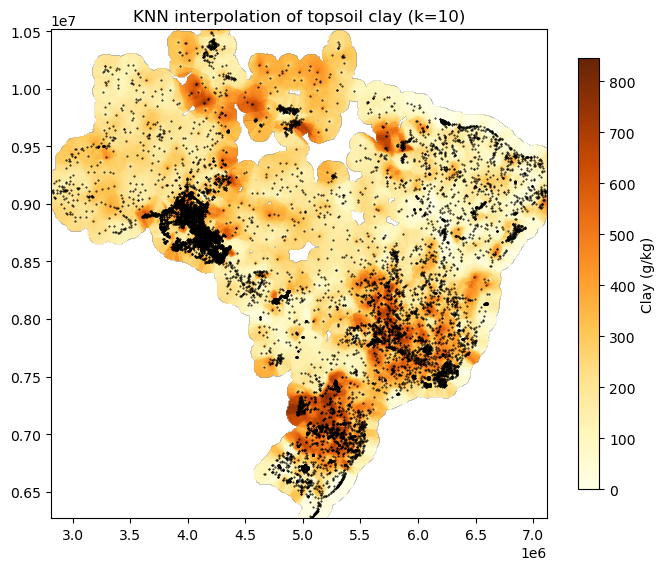

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
img = ax.imshow(clay_pred, origin="lower", extent=(xmin, xmax, ymin, ymax), cmap="YlOrBr")
topsoil.plot(ax=ax, color="k", markersize=0.2)
fig.colorbar(img, ax=ax, shrink=0.7, label="Clay (g/kg)")
ax.set_title("KNN interpolation of topsoil clay (k=10)");